In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)  # For reproducibility
pd.set_option('display.max_columns', None)  # Show all columns in the output
sns.set(style="whitegrid")  # Set seaborn style for plots


In [2]:
df = pd.read_csv("titanic_dataset.csv")

In [3]:
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["sex", "embarked", "class", "who", "deck", "embark_town", "alive", "alone", "survived", "pclass"]
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'fare', 'sibsp', 'parch']
Categorical columns: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive', 'alone', 'survived', 'pclass']


In [4]:
df_num = df[num_cols]

##### Detect Outliers using boxplots 

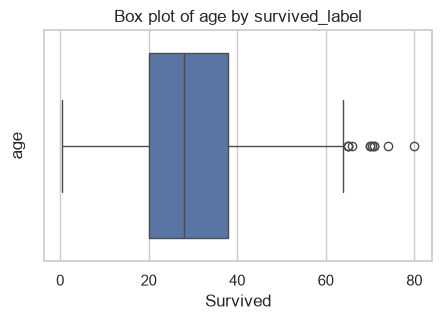

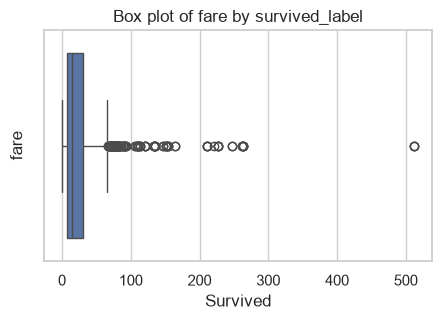

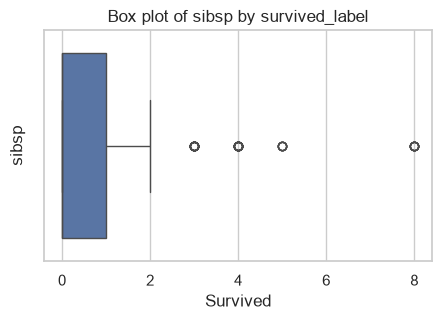

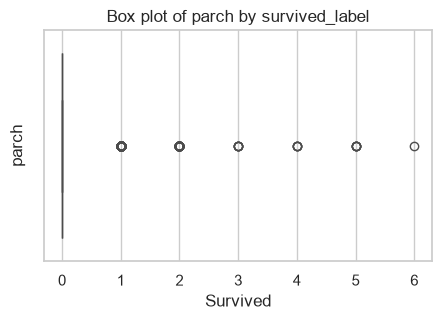

In [5]:
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Box plot of {col} by survived_label")
    plt.xlabel("Survived")
    plt.ylabel(col)
    plt.show()

#### IQR Method

In [22]:
def iqr_bounds(series, factor = 1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    iqr = Q3 - Q1
    lower_bound = Q1 - (factor * iqr)
    upper_bound = Q3 + (factor * iqr)
    return lower_bound, upper_bound,iqr

In [23]:
for col in num_cols:
    clean_col = df_num[col].dropna()
    lower_bound, upper_bound, iqr = iqr_bounds(clean_col)
    outliers_mask = (clean_col < lower_bound) | (clean_col > upper_bound)
    num_outliers = outliers_mask.sum()
    total = clean_col.shape[0]
    print(f"\nIQR method for {col}:")
    print(f"Outliers: {num_outliers} out of {total}")
    


IQR method for age:
Outliers: 11 out of 714

IQR method for fare:
Outliers: 116 out of 891

IQR method for sibsp:
Outliers: 46 out of 891

IQR method for parch:
Outliers: 213 out of 891


### Z-score method

######if Z > 3 outliers else not outliers, when using Z-score make sure the data is normally distributed, if not use IQR method.

In [24]:
z_threshold = 3.0 

for col in num_cols:
    col_clean = df_num[col].dropna()
    mean = col_clean.mean()
    std_dev = col_clean.std()
    z_scores = (col_clean - mean) / std_dev
    outliers_mask = np.abs(z_scores) > z_threshold
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]
    print(f"\nZ-score method for {col}:")
    print(f"Outliers: {num_outliers} out of {total}")



Z-score method for age:
Outliers: 2 out of 714

Z-score method for fare:
Outliers: 20 out of 891

Z-score method for sibsp:
Outliers: 30 out of 891

Z-score method for parch:
Outliers: 15 out of 891


#### 6. Stat comparison with & without Outliers

In [28]:
fare_clean = df_num["fare"].dropna()
fare_lower, fare_upper_bound, fare_iqr = iqr_bounds(fare_clean)


fare_inliers = fare_clean[(fare_clean >= fare_lower) & (fare_clean <=fare_upper_bound)]

print(f"\nFare column after removing outliers using IQR method:")
print(f"Outliers: {fare_clean.shape[0] - fare_inliers.shape[0]} out of {fare_clean.shape[0]}")



Fare column after removing outliers using IQR method:
Outliers: 116 out of 891
